In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Gas Pipeline Flow Simulation Using Python

Final Project

Author: Petar Mihaylov  
University: SofUni (Software University)  
Module: Math Concepts for Developers – Online  
Lecturer: Yordan Darakchiev

### Tools Used
- Python
- NumPy
- Matplotlib
- JupyterLab

## Motivation and Practical Application

Natural gas pipelines are critical infrastructure used to transport gas
over long distances from production sites to consumers.

The purpose of this project is to simulate the physical behaviour of gas
flow inside a pipeline and understand how key parameters influence:

- Transport capacity
- Pressure losses
- Flow regime
- Infrastructure requirements (e.g. compressor stations)

Such models are used in real-world applications including:

- Pipeline design and sizing
- Capacity planning
- Gas network optimization
- Energy trading and nomination systems

Companies operating large pipeline networks (e.g. transmission system operators)
rely on similar models to ensure efficient and safe gas delivery.

## Project Overview

Natural gas is transported through long-distance pipelines at high
pressure. Understanding the physical behaviour of gas flow is essential
for safe and efficient pipeline operation.

This project demonstrates a simplified simulation of natural gas flow
in a pipeline using Python.

The model will calculate and visualize:

• Compressibility factor (Z)  
• Natural gas density  
• Gas velocity in the pipeline  
• Reynolds number  
• Pressure losses along the pipeline

## 1. Natural Gas Composition

Natural gas is mainly composed of methane with small amounts of
other hydrocarbons and inert gases.

Typical composition:

Methane (C1) – 90 %  
Ethane (C2) – 5 %  
Propane (C3) – 3 %  
Carbon dioxide – 1 %  
Nitrogen – 1 %

Gas composition influences important thermodynamic properties such as
density and compressibility.

In [17]:
# Pipeline operating conditions

pressure_bar = 70      # pipeline pressure [bar]
temperature_K = 288    # temperature [K]

Pc_bar = 46            # pseudo-critical pressure [bar]
Tc_K = 190             # pseudo-critical temperature [K]

## 2. Compressibility Factor (Z)

At high pressure natural gas does not behave as an ideal gas.
The compressibility factor Z corrects the ideal gas equation.

Real gas equation:

PV = ZnRT

Where Z describes how much the gas deviates from ideal behaviour.

In [18]:
def calculate_z_factor(P_bar, T_K, Pc_bar, Tc_K):

    Pr = P_bar / Pc_bar
    Tr = T_K / Tc_K

    Z = 1 - (0.01 * Pr) + (0.005 * Tr)

    return Z

In [19]:
z = calculate_z_factor(
    pressure_bar,
    temperature_K,
    Pc_bar,
    Tc_K
)

print("Compressibility Factor Z =", round(z,3))

Compressibility Factor Z = 0.992


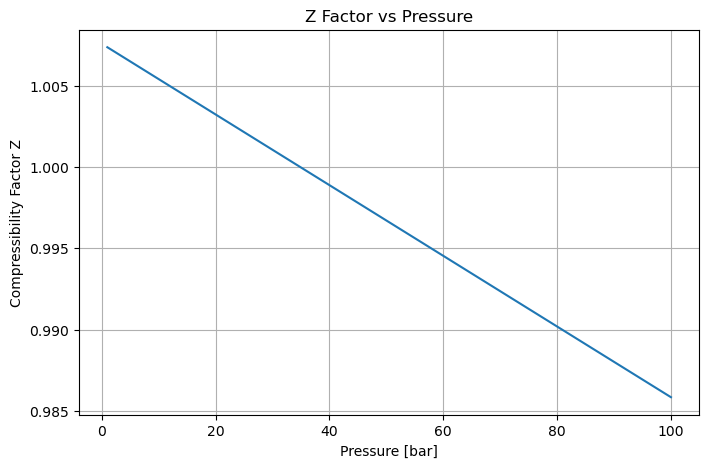

In [20]:
pressures_bar = np.linspace(1,100,50)

z_values = [
    calculate_z_factor(p,288,46,190)
    for p in pressures_bar
]

plt.figure(figsize=(8,5))

plt.plot(pressures_bar, z_values)

plt.xlabel("Pressure [bar]")
plt.ylabel("Compressibility Factor Z")

plt.title("Z Factor vs Pressure")

plt.grid()

plt.show()

## 3. Natural Gas Density

Gas density can be calculated using the real gas equation:

ρ = (P · M) / (Z · R · T)

Where:

ρ = Gas density [kg/m³]  
P = Pressure [Pa]  
M = Molar mass [kg/mol]  
Z = Compressibility factor  
R = Universal gas constant  
T = Temperature [K]

In [21]:
R = 8.314        # universal gas constant [J/(mol*K)]
M = 0.018        # molar mass of methane-rich natural gas [kg/mol]

pressure_Pa = pressure_bar * 100000

In [22]:
def calculate_gas_density(P_Pa, M, Z, R, T_K):

    density = (P_Pa * M) / (Z * R * T_K)

    return density

In [23]:
density = calculate_gas_density(
    pressure_Pa,
    M,
    z,
    R,
    temperature_K
)

print("Natural Gas Density =", round(density,2), "kg/m³")

Natural Gas Density = 53.03 kg/m³


## 4. Pipeline Parameters

In [24]:
length = 100000      # pipeline length [m]
diameter = 0.8       # pipeline diameter [m]
roughness = 0.000045 # internal pipe roughness [m]

## 5. Gas Velocity

Gas velocity is defined as:

$$
v = \frac{Q}{A}
$$

$$
Re = \frac{\rho \cdot v \cdot D}{\mu}
$$

In [25]:
flow_rate = 5     # volumetric flow rate [m³/s]

area = np.pi * (diameter/2)**2

velocity = flow_rate / area

print("Gas velocity =", round(velocity,2),"m/s")

Gas velocity = 9.95 m/s


In [26]:
viscosity = 1.1e-5

reynolds_number = (density * velocity * diameter) / viscosity

print("Reynolds number =", int(reynolds_number))
print("Gas velocity =", round(velocity,2),"m/s")

Reynolds number = 38361497
Gas velocity = 9.95 m/s


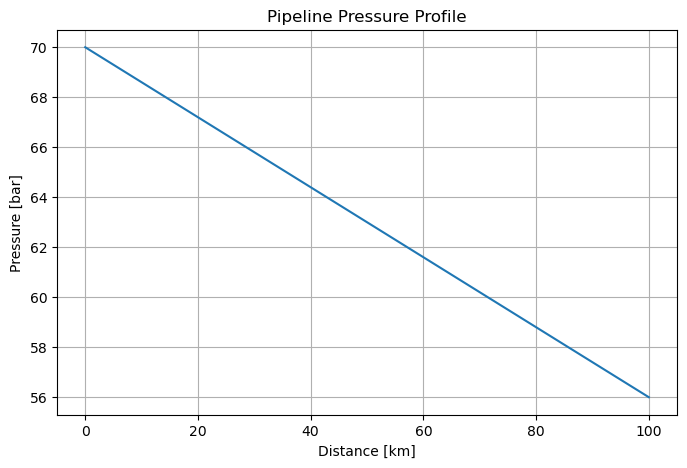

In [27]:
distance = np.linspace(0,length,100)

pressure_start = pressure_bar
pressure_end = pressure_bar * 0.8

pressure_profile = np.linspace(
    pressure_start,
    pressure_end,
    100
)

plt.figure(figsize=(8,5))

plt.plot(distance/1000, pressure_profile)

plt.xlabel("Distance [km]")
plt.ylabel("Pressure [bar]")

plt.title("Pipeline Pressure Profile")

plt.grid()

plt.show()

## 6. Influence of Pipeline Diameter

Pipeline diameter has a strong influence on gas velocity and the
overall capacity of the pipeline.

For a given volumetric flow rate:

v = Q / A

Where:

v = gas velocity [m/s]  
Q = volumetric flow rate [m³/s]  
A = pipeline cross-sectional area [m²]

A larger diameter increases the cross-sectional area, which reduces
gas velocity and decreases friction losses in the pipeline.

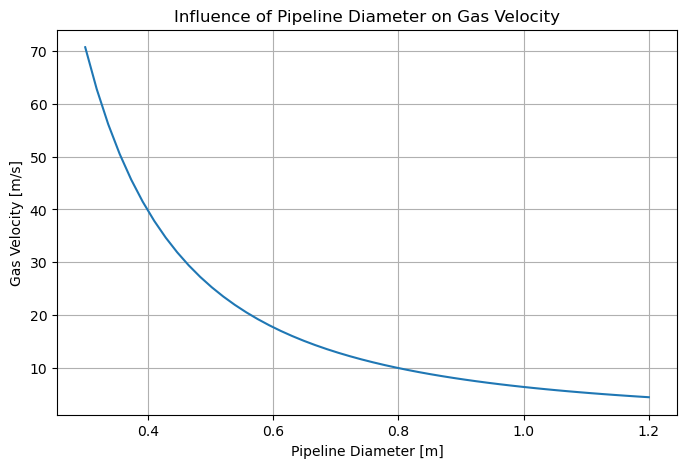

In [28]:
diameters = np.linspace(0.3,1.2,50)

velocities_diameter = []

for d in diameters:

    area_d = np.pi * (d/2)**2
    velocity_d = flow_rate / area_d

    velocities_diameter.append(velocity_d)

plt.figure(figsize=(8,5))

plt.plot(diameters, velocities_diameter)

plt.xlabel("Pipeline Diameter [m]")
plt.ylabel("Gas Velocity [m/s]")
plt.title("Influence of Pipeline Diameter on Gas Velocity")

plt.grid()

plt.show()

## 7. Pipeline Roughness and Friction Factor

Gas flowing through a pipeline experiences friction due to the
interaction between the gas and the internal pipe wall.

The magnitude of this friction depends on:

• Pipe roughness  
• Flow regime (Reynolds number)  
• Pipe diameter

The Darcy–Weisbach equation describes pressure losses in pipelines:

ΔP = f (L/D) (ρ v² / 2)

Where:

ΔP = pressure drop [Pa]  
f = friction factor  
L = pipeline length [m]  
D = pipeline diameter [m]

The friction factor depends on the relative roughness of the pipe.

Typical steel pipelines have roughness in the range of 0.000015–0.00005 m.

In [29]:
relative_roughness = roughness / diameter

print("Pipe Roughness =", roughness, "m")
print("Relative Roughness =", relative_roughness)

Pipe Roughness = 4.5e-05 m
Relative Roughness = 5.625e-05


## 8. Pipeline Capacity vs Diameter

Pipeline diameter has a major influence on the maximum gas transport
capacity of a transmission pipeline.

The volumetric flow rate is calculated as:

Q = A · v

Where:

Q = volumetric flow rate [m³/s]  
A = pipeline cross-sectional area [m²]  
v = gas velocity [m/s]

Since the area of a pipe increases with the square of the diameter,
even small increases in diameter can significantly increase the
transport capacity of the pipeline.

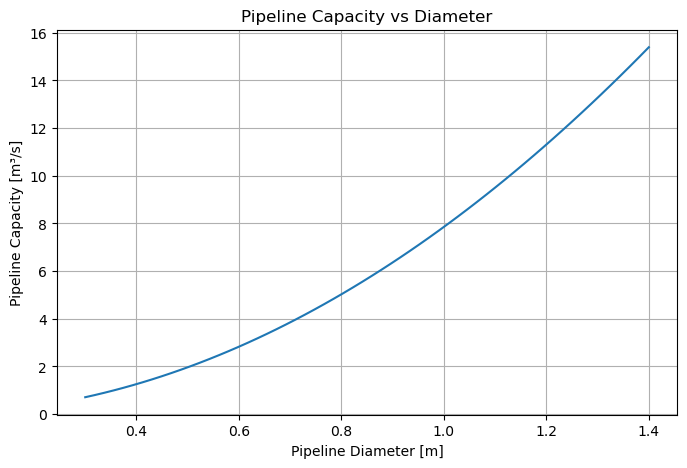

In [30]:
# Assume constant gas velocity

velocity_assumed = 10   # [m/s]

diameters = np.linspace(0.3,1.4,60)

capacities = []

for d in diameters:

    area = np.pi * (d/2)**2

    Q = area * velocity_assumed

    capacities.append(Q)

plt.figure(figsize=(8,5))

plt.plot(diameters, capacities)

plt.xlabel("Pipeline Diameter [m]")
plt.ylabel("Pipeline Capacity [m³/s]")

plt.title("Pipeline Capacity vs Diameter")

plt.grid()

plt.show()

## 9. Reynolds Number

The Reynolds number determines the flow regime inside the pipeline.

$$
Re = \frac{\rho \cdot v \cdot D}{\mu}
$$

Where:

Re = Reynolds number  
ρ = gas density [kg/m³]  
v = gas velocity [m/s]  
D = pipe diameter [m]  
μ = gas dynamic viscosity [Pa·s]

Flow regimes:

Re < 2300 → Laminar flow  
2300 – 4000 → Transitional flow  
Re > 4000 → Turbulent flow

Natural gas pipelines typically operate in the turbulent regime.

In [31]:
viscosity = 1.1e-5  # dynamic viscosity [Pa·s]

reynolds_number = (density * velocity * diameter) / viscosity

print("Reynolds Number =", int(reynolds_number))

Reynolds Number = 38361497


In [32]:
if reynolds_number < 2300:
    print("Flow Regime: Laminar")
elif reynolds_number < 4000:
    print("Flow Regime: Transitional")
else:
    print("Flow Regime: Turbulent")

Flow Regime: Turbulent


## 10. Friction Factor

The Darcy friction factor is used to calculate pressure losses in
pipelines.

For turbulent flow in rough pipes, an approximate relationship can
be used:

f = 0.25 / [log10((ε/D)/3.7)]²

Where:

f = friction factor  
ε = pipe roughness [m]  
D = pipe diameter [m]

In [33]:
friction_factor = 0.25 / (np.log10((roughness/diameter)/3.7))**2

print("Friction Factor =", round(friction_factor,4))

Friction Factor = 0.0108


## 11. Pipeline Pressure Drop

Pressure losses in pipelines occur because of friction between the gas
and the pipe wall.

The Darcy–Weisbach equation:

ΔP = f (L/D) (ρ v² / 2)

Where:

ΔP = pressure drop [Pa]  
f = friction factor  
L = pipeline length [m]  
D = pipeline diameter [m]

In [34]:
pressure_drop = friction_factor * (length/diameter) * (density * velocity**2 / 2)

print("Pressure Drop =", round(pressure_drop/100000,2), "bar")

Pressure Drop = 35.32 bar


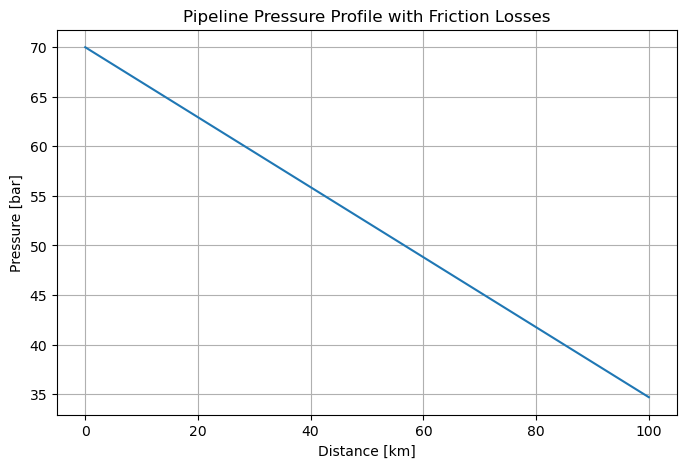

In [35]:
distance = np.linspace(0,length,100)

pressure_profile = pressure_bar - (pressure_drop/100000)*(distance/length)

plt.figure(figsize=(8,5))

plt.plot(distance/1000, pressure_profile)

plt.xlabel("Distance [km]")
plt.ylabel("Pressure [bar]")

plt.title("Pipeline Pressure Profile with Friction Losses")

plt.grid()

plt.show()

## 12. Compressor Station Simulation

In long-distance gas pipelines, compressor stations are installed to
compensate for pressure losses and maintain gas flow.

Typically, compressors are placed every 50–150 km.

They increase the gas pressure and allow continuous transport over long
distances.

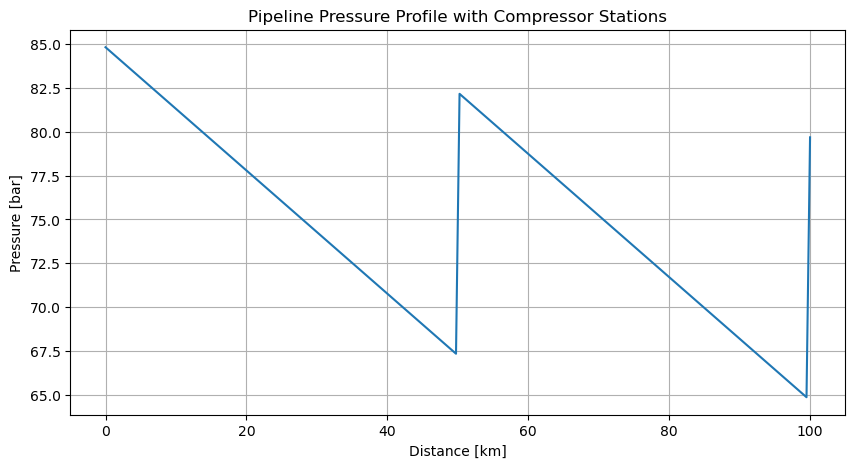

In [36]:
distance = np.linspace(0,length,200)

pressure_profile = []

pressure_current = pressure_bar

compressor_distance = 50000   # every 50 km
boost = 15                    # pressure increase [bar]

for x in distance:

    # pressure drop along pipeline
    pressure_current -= (pressure_drop/100000)/200

    # compressor boost
    if int(x) % compressor_distance < 500:
        pressure_current += boost

    pressure_profile.append(pressure_current)

plt.figure(figsize=(10,5))

plt.plot(distance/1000, pressure_profile)

plt.xlabel("Distance [km]")
plt.ylabel("Pressure [bar]")

plt.title("Pipeline Pressure Profile with Compressor Stations")

plt.grid()

plt.show()

## 13. Model Assumptions and Realism

This model is a simplified representation of gas flow in pipelines.
The following assumptions are made:

- Steady-state flow (no transient effects)
- Constant temperature (isothermal flow)
- Simplified gas composition (methane-dominated gas)
- Approximate compressibility factor
- No elevation effects
- Simplified friction factor correlation

### Realism Discussion

In real pipeline simulations:

- Compressibility is calculated using detailed equations of state
- Temperature varies along the pipeline
- Elevation and terrain are included
- Multi-phase flow may occur

Despite these simplifications, the model captures key physical trends:

- Pressure decreases with distance
- Larger diameters increase capacity
- Friction losses depend on velocity and roughness

Therefore, the model is suitable for **educational and conceptual analysis**,
but not for detailed engineering design.

## 14. Conclusions

This project demonstrated a simplified simulation of natural gas flow
in a transmission pipeline.

Key findings:

• Pipeline diameter strongly influences transport capacity  
• Gas velocity decreases with increasing diameter  
• Friction losses reduce pressure along the pipeline  
• Compressibility factor affects gas density calculations  
• Compressor stations are essential for long-distance gas transport  

The model provides a simplified but realistic representation of gas
pipeline operation and highlights key engineering principles used in
the natural gas industry.

## 15. Model Limitations

This model includes several simplifications:

• Gas composition is assumed constant (methane-rich gas)  
• Compressibility factor is approximated  
• Temperature is assumed constant  
• Elevation effects are neglected  
• Water dew point and condensation are not included  
• Friction factor is simplified  

Despite these assumptions, the model captures the main physical
behaviour of gas flow in pipelines.

## References

1. Çengel, Y. A., & Cimbala, J. M. – Fluid Mechanics
2. Fox, McDonald – Introduction to Fluid Mechanics
3. Crane Technical Paper No. 410 – Flow of Fluids
4. Standing, M. B. – Compressibility Factor Correlation
5. Darcy–Weisbach Equation – Fluid flow theory